Import reddit data as a .jsonl file, transform into a csv/data frame for ease of use

In [1]:
!pip install vaderSentiment

In [17]:
!pip install -U spacy

   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   ------ --------------------------------- 2.4/14.3 MB 11.2 MB/s eta 0:00:02
   ------------- -------------------------- 5.0/14.3 MB 11.6 MB/s eta 0:00:01
   -------------------- ------------------- 7.3/14.3 MB 11.9 MB/s eta 0:00:01
   --------------------------- ------------ 10.0/14.3 MB 11.9 MB/s eta 0:00:01
   ----------------------------------- ---- 12.6/14.3 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 14.3/14.3 MB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/652.5 kB ? eta -:--:--
   ---------------------------------------- 652.5/652.5 kB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 10.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   --------------- ------------------------ 2.4/6.2 MB 11.2 MB/s eta 0:00:01
   -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [2]:
# load json file as a csv
import pandas as pd
import json
import os

# filename = '/content/r_Drexel_posts.jsonl'  #json lines file, subreddit creation - 07/01/2026
# output_folder = 'content/output'

# Updated for personal environment
filename = 'r_Drexel_posts.jsonl'
output_folder = '/output'

with open(filename, encoding='utf-8') as f:
    lines = f.read().splitlines()

my_dict = {}
for i, line in enumerate(lines):
    try:
        my_dict[i] = json.loads(line)
    except:
        pass

df_raw = pd.DataFrame.from_dict(my_dict).T
df_raw.shape


(32053, 134)

In [3]:
df_raw.head()

,archived,author,author_flair_background_color,author_flair_css_class,author_flair_richtext,author_flair_text,author_flair_text_color,author_flair_type,brand_safe,can_gild,...,is_gallery,call_to_action,author_is_blocked,_meta,previous_selftext,location_lat,location_long,location_name,websocket_url,outbound_link
0,True,brtw,None,textflair,"[{'e': 'text', 't': 'Alumni | Cheese'}]",Alumni | Cheese,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,brtw,None,textflair,"[{'e': 'text', 't': 'Alumni | Cheese'}]",Alumni | Cheese,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,True,[deleted],,None,NaN,None,dark,NaN,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,True,Sporknight,None,None,[],None,None,text,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,True,kjhobin,None,textflair,"[{'e': 'text', 't': 'Information Systems Alum ...",Information Systems Alum '13,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# remove deleted, removed posts
df_raw = df_raw[~df_raw["author"].isin(["[removed]", "[deleted]", ""])]
df_raw = df_raw[~df_raw["selftext"].isin(["[removed]", "[deleted]", ""])]

# keep only relavent columns
df_filtered = df_raw[["id", "author", "created_utc", "title", "selftext"]].copy()

#combine title and selftext into one field
df_filtered["text"] = df_filtered["title"].fillna("") + " " + df_filtered["selftext"].fillna("")

df_filtered.shape

(22132, 6)

In [5]:
# clean up the reddit data
import re

def clean_reddit_text(text):
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)   # [text](link) -> text
    text = re.sub(r'&amp;|&gt;|&lt;', ' ', text)             # HTML entities
    text = re.sub(r'\*{1,2}([^\*]+)\*{1,2}', r'\1', text)    # **bold**/*italic*
    text = re.sub(r'/r/\w+|/u/\w+|r/\w+|u/\w+', ' ', text)   # subreddit/user mentions
    text = re.sub(r'\n+', ' ', text)                         # newlines
    return text

df_filtered["text_clean"] = df_filtered["text"].apply(clean_reddit_text)

In [19]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 8.4 MB/s eta 0:00:02
     -------- ------------------------------- 2.6/12.8 MB 7.9 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 9.2 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 10.1 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 10.0 MB/s eta 0:00:01
     ----------------------------------- --- 11.5/12.8 MB 10.2 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 9.4 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [6]:
# tokenzie and lemmatize
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

docs = df_filtered["text_clean"].tolist()

tokens_list = []
for doc in nlp.pipe(docs, batch_size=100):
    tokens_list.append([
        token.lemma_.lower() for token in doc
        if token.is_alpha and not token.is_stop and len(token) > 2
    ])

df_filtered["tokens"] = tokens_list

In [7]:
from collections import Counter

# combined stopword list first and second wave of words
custom_stopwords = {
    "drexel", "know", "like", "look", "want", "get", "thank",
    "take", "need", "time", "go", "good", "help", "find",
    "think", "question", "wonder", "try", "guy", "hey", "pay"
}

custom_stopwords.update({
    "people", "term", "experience", "plan", "live", "interested",
    "offer", "start", "week", "come", "say", "feel", "hear", "place",
    "ask", "new", "things", "currently", "way", "day", "thing", "lot", "let"
})

# apply filter to token columns
df_filtered["tokens"] = df_filtered["tokens"].apply(
    lambda tokens: [t for t in tokens if t not in custom_stopwords]
)

# 3. rebuild tokens from the filtered column and recheck frequencies
all_tokens = [t for tokens in df_filtered["tokens"] for t in tokens]
Counter(all_tokens).most_common(40)

[('class', 6474),
 ('student', 6070),
 ('year', 4876),
 ('work', 3404),
 ('major', 3204),
 ('campus', 3174),
 ('program', 2930),
 ('course', 2555),
 ('school', 2517),
 ('fall', 2210),
 ('room', 1986),
 ('freshman', 1889),
 ('job', 1827),
 ('university', 1800),
 ('email', 1689),
 ('apply', 1669),
 ('study', 1637),
 ('summer', 1636),
 ('online', 1628),
 ('coop', 1628),
 ('engineering', 1626),
 ('housing', 1609),
 ('college', 1557),
 ('professor', 1539),
 ('month', 1418),
 ('quarter', 1413),
 ('interview', 1388),
 ('spring', 1384),
 ('apartment', 1381),
 ('advice', 1342),
 ('roommate', 1342),
 ('accept', 1310),
 ('free', 1308),
 ('credit', 1302),
 ('transfer', 1269),
 ('lease', 1254),
 ('graduate', 1246),
 ('aid', 1210),
 ('tell', 1196),
 ('friend', 1194)]

In [22]:
!pip install gensim

In [8]:
# build the dictionary and corpus
from gensim import corpora

dictionary = corpora.Dictionary(df_filtered["tokens"])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df_filtered["tokens"]]

In [9]:
# decide which k to use
from gensim.models import LdaModel, CoherenceModel

for k in [2, 3, 4, 5, 6, 7]:
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42)
    cm = CoherenceModel(model=lda, texts=df_filtered["tokens"], dictionary=dictionary, coherence='c_v')
    print(k, cm.get_coherence())

2 0.5520230935555752
3 0.5292972999983293
4 0.5084243728923933
5 0.5473026834054726
6 0.5413836350240554
7 0.5537351662722125


In [10]:
# use K=7
lda_7 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=7, passes=15, random_state=42)
for idx, topic in lda_7.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.015*"comcast" + 0.012*"campus" + 0.012*"student" + 0.010*"friend" + 0.008*"club" + 0.007*"food" + 0.007*"group" + 0.006*"open" + 0.006*"work" + 0.005*"hour"
Topic 1: 0.030*"interview" + 0.030*"job" + 0.027*"coop" + 0.027*"work" + 0.027*"major" + 0.022*"round" + 0.022*"engineering" + 0.017*"accept" + 0.017*"engineer" + 0.016*"employer"
Topic 2: 0.039*"student" + 0.034*"program" + 0.033*"year" + 0.026*"school" + 0.015*"college" + 0.014*"aid" + 0.014*"transfer" + 0.014*"international" + 0.012*"apply" + 0.012*"financial"
Topic 3: 0.027*"room" + 0.024*"apartment" + 0.024*"lease" + 0.022*"roommate" + 0.021*"campus" + 0.019*"housing" + 0.017*"month" + 0.015*"rent" + 0.015*"summit" + 0.012*"bed"
Topic 4: 0.068*"class" + 0.030*"course" + 0.016*"professor" + 0.016*"exam" + 0.015*"online" + 0.012*"credit" + 0.012*"quarter" + 0.012*"math" + 0.010*"grade" + 0.010*"summer"
Topic 5: 0.019*"sell" + 0.015*"ticket" + 0.015*"sale" + 0.013*"buy" + 0.010*"free" + 0.010*"survey" + 0.009*"item" + 

# VADER

In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [12]:
analyzer = SentimentIntensityAnalyzer()

# Combine title + selftext into one field to analyze
df_filtered['full_text'] = df_filtered['title'].fillna('') + ' ' + df_filtered['selftext'].fillna('')

In [13]:
# Run VADER on each post and pull out the scores
def get_vader_scores(text):
    scores = analyzer.polarity_scores(text)
    return pd.Series([scores['neg'], scores['neu'], scores['pos'], scores['compound']])

df_filtered[['neg', 'neu', 'pos', 'compound']] = df_filtered['full_text'].apply(get_vader_scores)

In [14]:
# Label overall sentiment based on compound score
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_filtered['sentiment'] = df_filtered['compound'].apply(classify_sentiment)

df_filtered[['title', 'compound', 'sentiment']].head(10)

,title,compound,sentiment
9,Incoming Freshman,0.7998,positive
13,Any other sophomore engineering and/or non-eng...,0.7469,positive
14,How do you find out what books you need for cl...,0.8915,positive
15,Some important questions for survival...,0.9667,positive
17,I know you guys are there...,-0.8176,negative
18,Apparently Drexel has the second fastest inter...,0.8020,positive
19,Drexel Rubik's Cube Club!,0.8053,positive
20,"Thinking of transferring to Drexel, need opini...",0.9927,positive
22,Where do you guys find parking?,-0.2359,negative
23,Inter-university TF2 anyone? Both Temple and D...,-0.1230,negative


In [15]:
# Compare to naive baseline

# Minimal "naive" positive/negative word list
positive_words = {
    'good', 'great', 'love', 'best', 'awesome', 'happy', 'amazing',
    'excellent', 'nice', 'perfect', 'fantastic', 'wonderful', 'thank',
    'thanks', 'like', 'beautiful', 'glad', 'enjoy', 'positive', 'win'
}
negative_words = {
    'bad', 'worst', 'hate', 'terrible', 'awful', 'sad', 'angry',
    'horrible', 'disappointing', 'poor', 'annoying', 'negative', 'lose',
    'fail', 'wrong', 'problem', 'issue', 'worse', 'sucks', 'broken'
}

def naive_sentiment(text):
    words = str(text).lower().split()
    words = [w.strip('.,!?";:()') for w in words]
    pos_count = sum(1 for w in words if w in positive_words)
    neg_count = sum(1 for w in words if w in negative_words)
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

df_filtered['naive_sentiment'] = df_filtered['full_text'].apply(naive_sentiment)

In [17]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import pandas as pd

# Overall agreement rates
naive_agreement = (df_filtered['sentiment'] == df_filtered['naive_sentiment']).mean()

print(f"VADER vs Naive word-count agreement: {naive_agreement:.1%}")

# Cohen's kappa (agreement adjusted for chance)
print(f"Cohen's kappa (VADER vs Naive): {cohen_kappa_score(df_filtered['sentiment'], df_filtered['naive_sentiment']):.3f}")

# Confusion matrix: where does naive baseline diverge from VADER?
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(df_filtered['sentiment'], df_filtered['naive_sentiment'], labels=labels)
cm_df = pd.DataFrame(cm, index=[f'VADER_{l}' for l in labels], columns=[f'Naive_{l}' for l in labels])
print(cm_df)

VADER vs Naive word-count agreement: 53.8%
Cohen's kappa (VADER vs Naive): 0.285
                Naive_negative  Naive_neutral  Naive_positive
VADER_negative             720           2654             621
VADER_neutral               31           3232              50
VADER_positive             301           6572            7951


In [18]:
# Find disagreements, especially where naive missed negation
disagreements = df_filtered[df_filtered['sentiment'] != df_filtered['naive_sentiment']].copy()

# Flag posts containing negation words — naive counter has no way to handle these
negation_words = ['not', "n't", 'no', 'never', 'without']
disagreements['has_negation'] = disagreements['full_text'].str.lower().apply(
    lambda t: any(neg in t.split() or neg in t for neg in negation_words)
)

print(f"Total disagreements: {len(disagreements)}")
print(f"Disagreements involving negation: {disagreements['has_negation'].sum()}")

# Show concrete examples for a write-up
example_cols = ['full_text', 'compound', 'sentiment', 'naive_sentiment']
print("\nExamples where negation likely tripped up the naive method:")
print(disagreements[disagreements['has_negation']][example_cols].head(10).to_string())

Total disagreements: 10229
Disagreements involving negation: 6071

Examples where negation likely tripped up the naive method:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

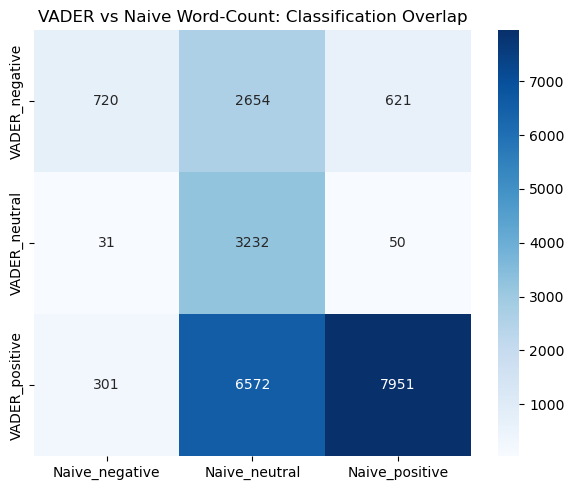

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
import seaborn as sns
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('VADER vs Naive Word-Count: Classification Overlap')
plt.tight_layout()
plt.savefig('vader_vs_naive_confusion.png', dpi=150)
plt.show()